In [1]:
!pip install kagglehub
!pip install opencv-python scikit-image matplotlib

In [2]:
import kagglehub

path = kagglehub.dataset_download("ipateam/nuinsseg")
print("Dataset downloaded at = ", path)

100%|██████████| 1.52G/1.52G [00:19<00:00, 82.5MB/s]

Extracting files...


Dataset downloaded at =  /root/.cache/kagglehub/datasets/ipateam/nuinsseg/versions/5


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import measure
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage

Inside tissue folder = 
['weighted_maps', 'Imagj_zips', 'weighted_maps_erode', 'mask binary without border erode', 'vague areas', 'label masks modify', 'stacked mask', 'nuclei border', 'mask binary without border', 'overlay_save_path', 'label masks', 'distance maps', 'tissue images', 'mask binary']
Image folder =  /root/.cache/kagglehub/datasets/ipateam/nuinsseg/versions/5/human kidney/tissue images
Mask folder =  /root/.cache/kagglehub/datasets/ipateam/nuinsseg/versions/5/human kidney/mask binary
Total images found =  11


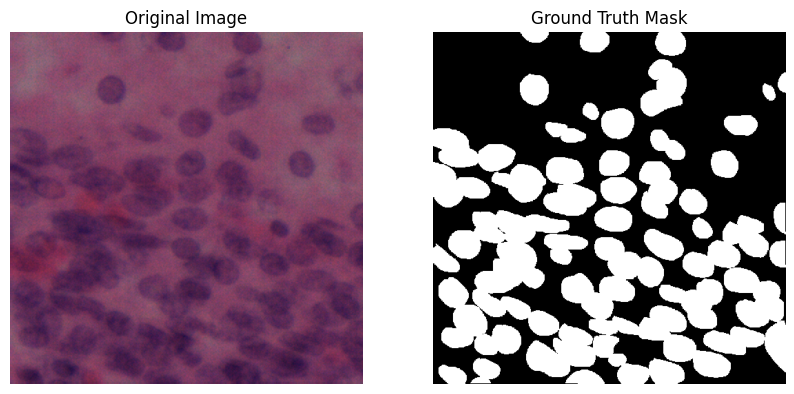

In [4]:
tissue_folder = os.path.join(path, "human kidney")
print("Inside tissue folder = ")
print(os.listdir(tissue_folder))

subfolders = os.listdir(tissue_folder)
image_dir = None
mask_dir = None

for folder in subfolders:
    if "image" in folder.lower():
        image_dir = os.path.join(tissue_folder, folder)
    if "mask" in folder.lower() or "label" in folder.lower():
        mask_dir = os.path.join(tissue_folder, folder)

print("Image folder = ", image_dir)
print("Mask folder = ", mask_dir)

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print("Total images found = ", len(image_files))

img = cv2.imread(os.path.join(image_dir, image_files[0]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_dir, mask_files[0]), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

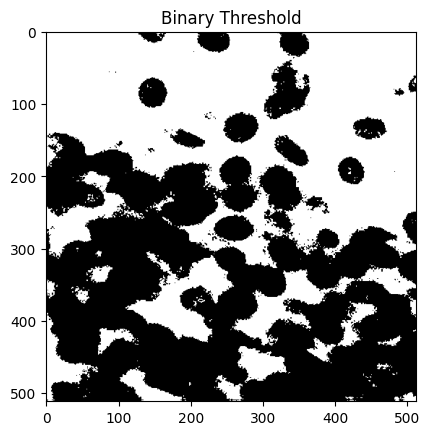

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Binary Threshold")
plt.show()

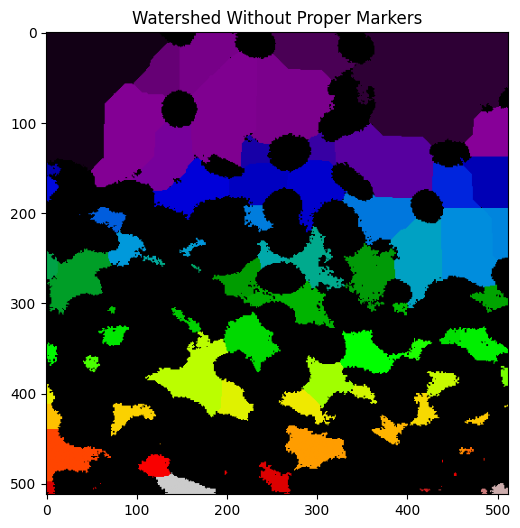

In [6]:
distance = ndimage.distance_transform_edt(thresh)
coords = peak_local_max(distance, footprint=np.ones((25, 25)), labels=thresh)
mask_local = np.zeros(distance.shape, dtype=bool)
mask_local[tuple(coords.T)] = True

markers = measure.label(mask_local)
labels_ws_no_marker = watershed(-distance, markers, mask=thresh)

plt.figure(figsize=(6,6))
plt.imshow(labels_ws_no_marker, cmap='nipy_spectral')
plt.title("Watershed Without Proper Markers")
plt.show()

Image Operations

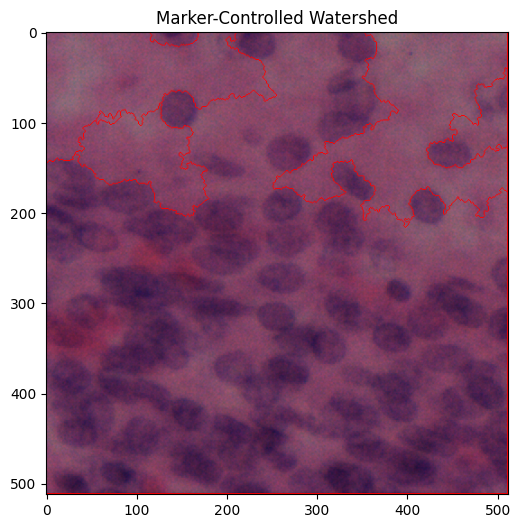

In [7]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

ret, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

img_copy = img.copy()
markers = cv2.watershed(img_copy, markers)

img_copy[markers == -1] = [255,0,0]

plt.figure(figsize=(6,6))
plt.imshow(img_copy)
plt.title("Marker-Controlled Watershed")
plt.show()

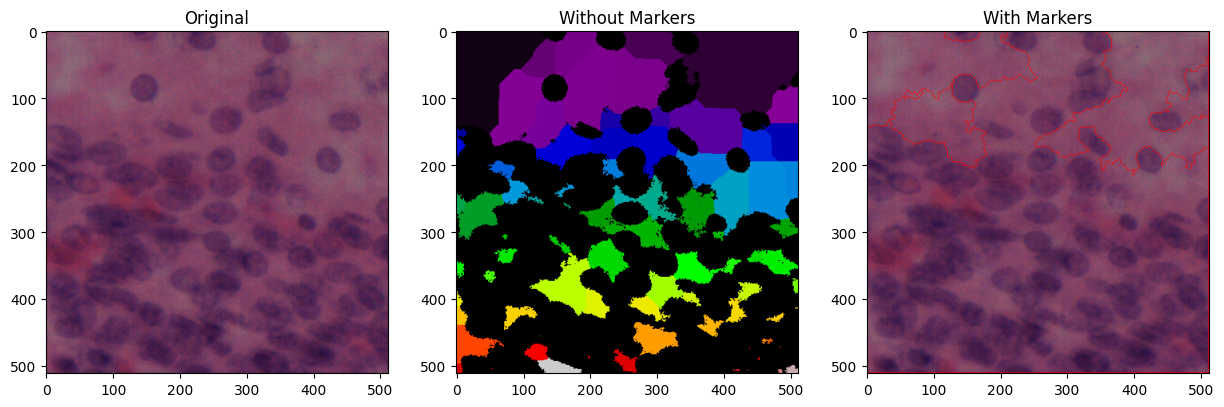

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(labels_ws_no_marker, cmap='nipy_spectral')
plt.title("Without Markers")

plt.subplot(1,3,3)
plt.imshow(img_copy)
plt.title("With Markers")

plt.show()

In [9]:
print("Objects without markers = ",
      len(np.unique(labels_ws_no_marker)))

print("Objects with markers = ",
      len(np.unique(markers)))

Objects without markers =  93
Objects with markers =  6
